# EMPLOYEE ATTRITION PREDICTION

**Problem Statement:** Predict whether an employee will be resign or not.

**Dataset:** Employee Attrition Dataset ( Keggle Link : https://www.kaggle.com/datasets/whenamancodes/hr-employee-attrition )

This notebook demonstrates the full project structure:
1. EDA
2. Cleaning & Preprocessing
3. Train Multiple ML models
4. Compare models using metrics
5. Select & justify the best model
6. Hyper-Parameter Tuning the Best Model
7. Predict on unseen data

## 1. Importing Libraries

In [366]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split,GridSearchCV
from sklearn.preprocessing import LabelEncoder,OneHotEncoder,StandardScaler
from sklearn.compose import ColumnTransformer
from imblearn.over_sampling import SMOTE
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import f1_score,accuracy_score,recall_score,precision_score,confusion_matrix,classification_report,roc_auc_score

## 2. Load Dataset

In [ ]:
df = pd.read_csv('../datasets/HR Employee Attrition.csv')
df.head()

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2


## 3. Data Preperation

In [368]:
df.columns

Index(['Age', 'Attrition', 'BusinessTravel', 'DailyRate', 'Department',
       'DistanceFromHome', 'Education', 'EducationField', 'EmployeeCount',
       'EmployeeNumber', 'EnvironmentSatisfaction', 'Gender', 'HourlyRate',
       'JobInvolvement', 'JobLevel', 'JobRole', 'JobSatisfaction',
       'MaritalStatus', 'MonthlyIncome', 'MonthlyRate', 'NumCompaniesWorked',
       'Over18', 'OverTime', 'PercentSalaryHike', 'PerformanceRating',
       'RelationshipSatisfaction', 'StandardHours', 'StockOptionLevel',
       'TotalWorkingYears', 'TrainingTimesLastYear', 'WorkLifeBalance',
       'YearsAtCompany', 'YearsInCurrentRole', 'YearsSinceLastPromotion',
       'YearsWithCurrManager'],
      dtype='object')

In [369]:
needed_cols = ['Age','Attrition','Department','Education','Gender','JobLevel','JobSatisfaction','MonthlyIncome','OverTime','PerformanceRating','TotalWorkingYears','WorkLifeBalance','YearsSinceLastPromotion']
total_cols = df.columns
df = df[needed_cols]
df.head()

,Age,Attrition,Department,Education,Gender,JobLevel,JobSatisfaction,MonthlyIncome,OverTime,PerformanceRating,TotalWorkingYears,WorkLifeBalance,YearsSinceLastPromotion
0,41,Yes,Sales,2,Female,2,4,5993,Yes,3,8,1,0
1,49,No,Research & Development,1,Male,2,2,5130,No,4,10,3,1
2,37,Yes,Research & Development,2,Male,1,3,2090,Yes,3,7,3,0
3,33,No,Research & Development,4,Female,1,3,2909,Yes,3,8,3,3
4,27,No,Research & Development,1,Male,1,2,3468,No,3,6,3,2


## 4. EDA

In [370]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 13 columns):
 #   Column                   Non-Null Count  Dtype 
---  ------                   --------------  ----- 
 0   Age                      1470 non-null   int64 
 1   Attrition                1470 non-null   object
 2   Department               1470 non-null   object
 3   Education                1470 non-null   int64 
 4   Gender                   1470 non-null   object
 5   JobLevel                 1470 non-null   int64 
 6   JobSatisfaction          1470 non-null   int64 
 7   MonthlyIncome            1470 non-null   int64 
 8   OverTime                 1470 non-null   object
 9   PerformanceRating        1470 non-null   int64 
 10  TotalWorkingYears        1470 non-null   int64 
 11  WorkLifeBalance          1470 non-null   int64 
 12  YearsSinceLastPromotion  1470 non-null   int64 
dtypes: int64(9), object(4)
memory usage: 149.4+ KB


In [371]:
df.describe()

,Age,Education,JobLevel,JobSatisfaction,MonthlyIncome,PerformanceRating,TotalWorkingYears,WorkLifeBalance,YearsSinceLastPromotion
count,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000
mean,36.923810,2.912925,2.063946,2.728571,6502.931293,3.153741,11.279592,2.761224,2.187755
std,9.135373,1.024165,1.106940,1.102846,4707.956783,0.360824,7.780782,0.706476,3.222430
min,18.000000,1.000000,1.000000,1.000000,1009.000000,3.000000,0.000000,1.000000,0.000000
25%,30.000000,2.000000,1.000000,2.000000,2911.000000,3.000000,6.000000,2.000000,0.000000
50%,36.000000,3.000000,2.000000,3.000000,4919.000000,3.000000,10.000000,3.000000,1.000000
75%,43.000000,4.000000,3.000000,4.000000,8379.000000,3.000000,15.000000,3.000000,3.000000
max,60.000000,5.000000,5.000000,4.000000,19999.000000,4.000000,40.000000,4.000000,15.000000


In [372]:
df.describe(include=['object'])

,Attrition,Department,Gender,OverTime
count,1470,1470,1470,1470
unique,2,3,2,2
top,No,Research & Development,Male,No
freq,1233,961,882,1054


In [373]:
df.isnull().sum()


Age                        0
Attrition                  0
Department                 0
Education                  0
Gender                     0
JobLevel                   0
JobSatisfaction            0
MonthlyIncome              0
OverTime                   0
PerformanceRating          0
TotalWorkingYears          0
WorkLifeBalance            0
YearsSinceLastPromotion    0
dtype: int64

In [374]:
df.duplicated().sum()

np.int64(0)

In [375]:
df.Attrition.value_counts(normalize=True)

Attrition
No     0.838776
Yes    0.161224
Name: proportion, dtype: float64

<Axes: xlabel='Attrition', ylabel='count'>

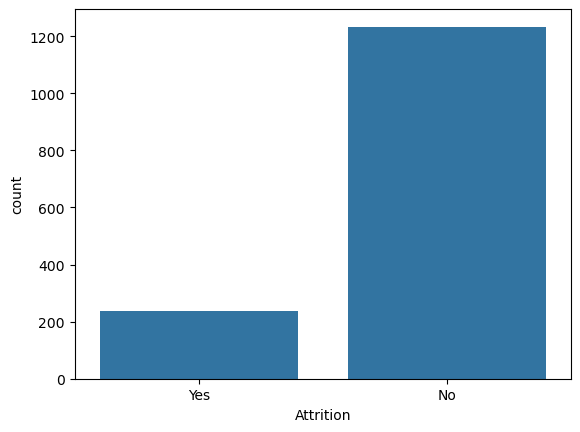

In [376]:
sns.countplot(x = df.Attrition)

Age                        1.000000
TotalWorkingYears          0.680381
JobLevel                   0.509604
MonthlyIncome              0.497855
YearsSinceLastPromotion    0.216513
Education                  0.208034
PerformanceRating          0.001904
JobSatisfaction           -0.004892
WorkLifeBalance           -0.021490
Name: Age, dtype: float64

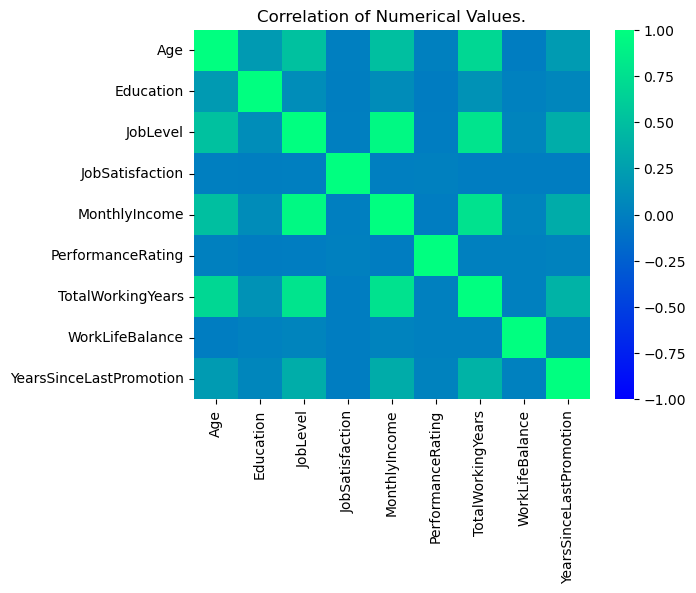

In [377]:
corr = df.select_dtypes(exclude=['object']).corr()
sns.heatmap(corr, vmin=-1, vmax=1, cmap='winter')
plt.title("Correlation of Numerical Values.")
corr['Age'].sort_values(ascending=False)

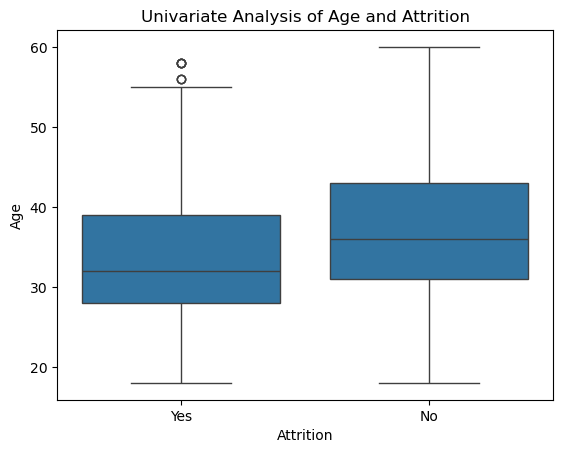

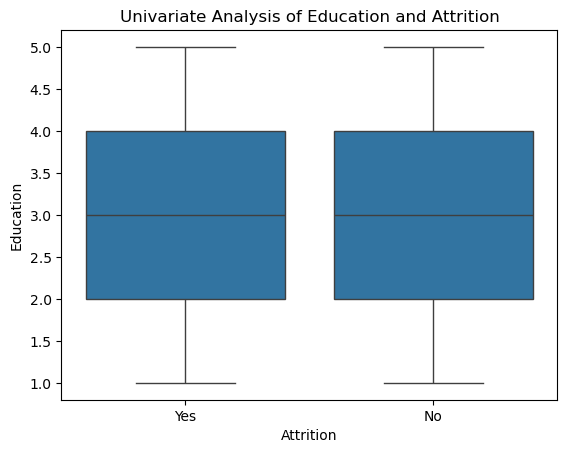

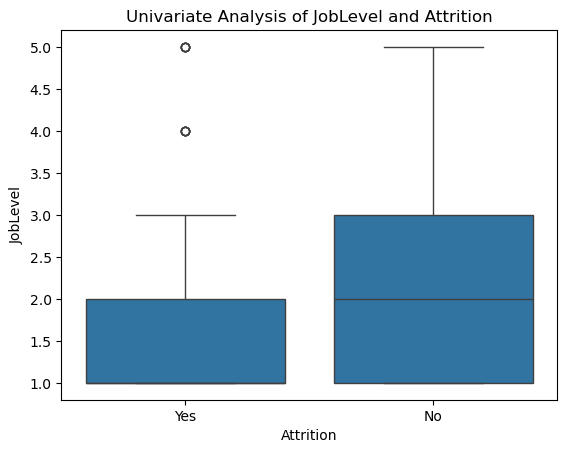

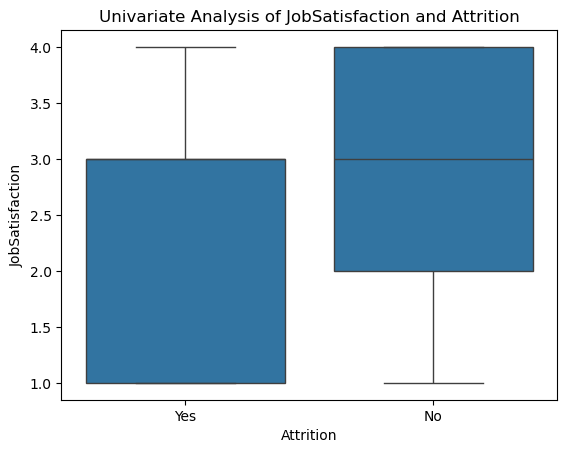

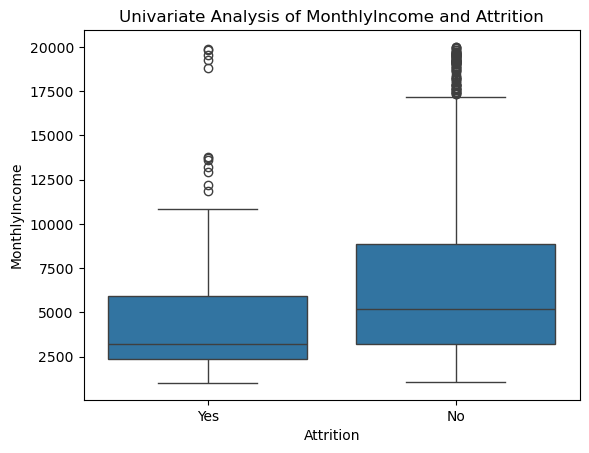

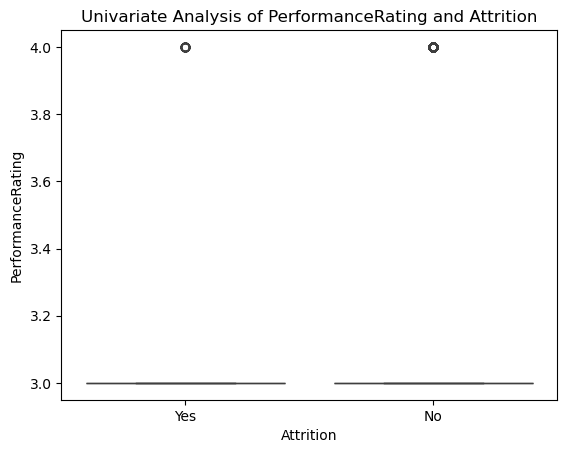

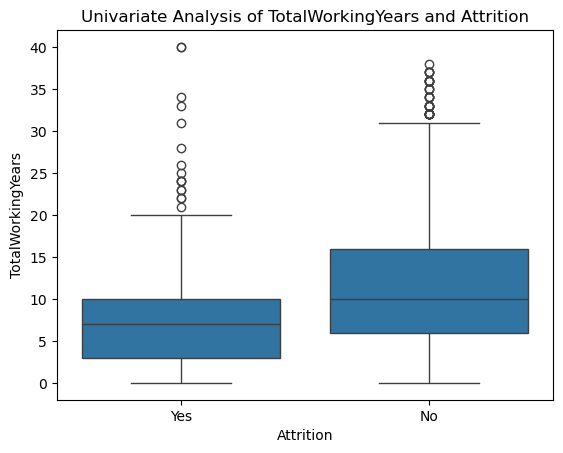

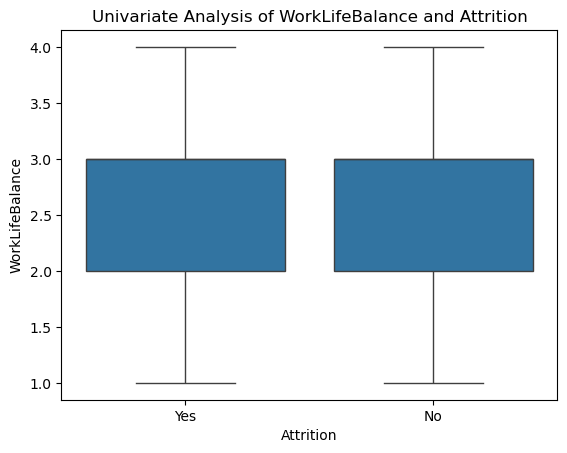

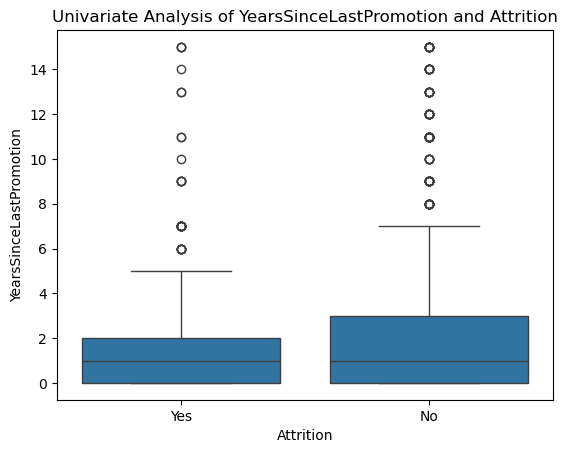

In [378]:
for cols in list(df.select_dtypes(exclude=['object']).columns):
    sns.boxplot(x= df.Attrition, y=df[cols])
    plt.title(f"Univariate Analysis of {cols} and Attrition")
    plt.show()

<Axes: xlabel='OverTime', ylabel='count'>

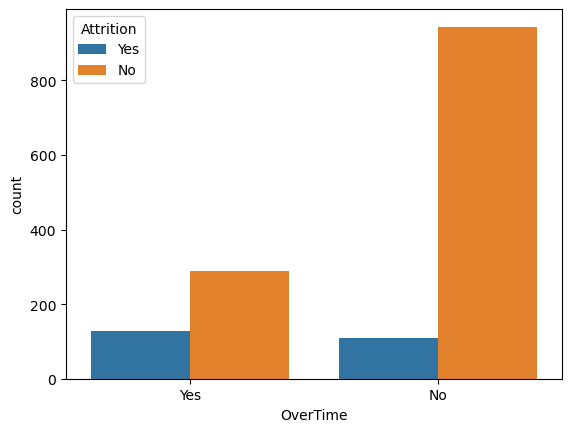

In [379]:
sns.countplot(x=df.OverTime, hue=df.Attrition)

<Axes: xlabel='Department', ylabel='count'>

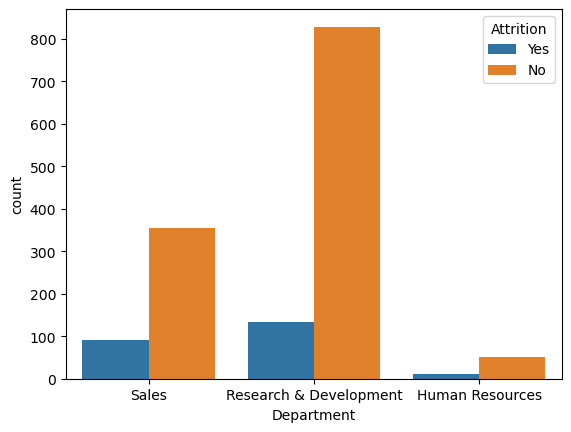

In [380]:
sns.countplot(x=df.Department, hue=df.Attrition)

<Axes: xlabel='Gender', ylabel='count'>

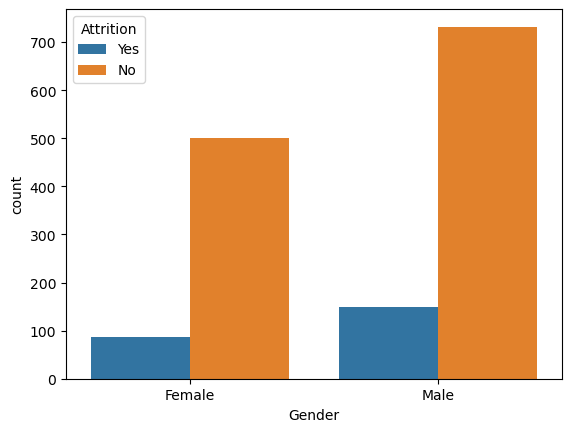

In [381]:
sns.countplot(x=df.Gender, hue=df.Attrition)


**EDA Takeaways:**
1. No null or duplicated values.
2. Target Class is imbalanced (NO : ~84% | YES : ~16%)

## 5. Data Preprocessing

In [382]:
X = df.drop('Attrition', axis=1)
y= df.Attrition
X.head()

,Age,Department,Education,Gender,JobLevel,JobSatisfaction,MonthlyIncome,OverTime,PerformanceRating,TotalWorkingYears,WorkLifeBalance,YearsSinceLastPromotion
0,41,Sales,2,Female,2,4,5993,Yes,3,8,1,0
1,49,Research & Development,1,Male,2,2,5130,No,4,10,3,1
2,37,Research & Development,2,Male,1,3,2090,Yes,3,7,3,0
3,33,Research & Development,4,Female,1,3,2909,Yes,3,8,3,3
4,27,Research & Development,1,Male,1,2,3468,No,3,6,3,2


In [383]:
y.head()

0    Yes
1     No
2    Yes
3     No
4     No
Name: Attrition, dtype: object

In [384]:
Scaling_cols = ['Age','MonthlyIncome','TotalWorkingYears','YearsSinceLastPromotion']
Encoding_cols = X.select_dtypes(include=['object']).columns
Scaling_cols,Encoding_cols

(['Age', 'MonthlyIncome', 'TotalWorkingYears', 'YearsSinceLastPromotion'],
 Index(['Department', 'Gender', 'OverTime'], dtype='object'))

In [385]:
encoder = OneHotEncoder(drop='first')
scaler = StandardScaler()
le = LabelEncoder()
y = le.fit_transform(y)
preprocessor = ColumnTransformer([
    ('StandardScaler',scaler,Scaling_cols),
    ('OneHotEncoder',encoder,Encoding_cols)
],remainder='passthrough')
X = preprocessor.fit_transform(X)

In [386]:
X,y

(array([[ 0.4463504 , -0.10834951, -0.42164246, ...,  4.        ,
          3.        ,  1.        ],
        [ 1.32236521, -0.29171859, -0.1645114 , ...,  2.        ,
          4.        ,  3.        ],
        [ 0.008343  , -0.93765369, -0.55020799, ...,  3.        ,
          3.        ,  3.        ],
        ...,
        [-1.08667552, -0.07669019, -0.67877352, ...,  2.        ,
          4.        ,  3.        ],
        [ 1.32236521, -0.23647414,  0.7354473 , ...,  2.        ,
          3.        ,  2.        ],
        [-0.32016256, -0.44597809, -0.67877352, ...,  3.        ,
          3.        ,  4.        ]], shape=(1470, 13)),
 array([1, 0, 1, ..., 0, 0, 0], shape=(1470,)))

In [387]:
X = pd.DataFrame(X, columns=preprocessor.get_feature_names_out())
y = pd.DataFrame(y, columns=['Attrition'])
X.head()

,StandardScaler__Age,StandardScaler__MonthlyIncome,StandardScaler__TotalWorkingYears,StandardScaler__YearsSinceLastPromotion,OneHotEncoder__Department_Research & Development,OneHotEncoder__Department_Sales,OneHotEncoder__Gender_Male,OneHotEncoder__OverTime_Yes,remainder__Education,remainder__JobLevel,remainder__JobSatisfaction,remainder__PerformanceRating,remainder__WorkLifeBalance
0,0.446350,-0.108350,-0.421642,-0.679146,0.0,1.0,0.0,1.0,2.0,2.0,4.0,3.0,1.0
1,1.322365,-0.291719,-0.164511,-0.368715,1.0,0.0,1.0,0.0,1.0,2.0,2.0,4.0,3.0
2,0.008343,-0.937654,-0.550208,-0.679146,1.0,0.0,1.0,1.0,2.0,1.0,3.0,3.0,3.0
3,-0.429664,-0.763634,-0.421642,0.252146,1.0,0.0,0.0,1.0,4.0,1.0,3.0,3.0,3.0
4,-1.086676,-0.644858,-0.678774,-0.058285,1.0,0.0,1.0,0.0,1.0,1.0,2.0,3.0,3.0


In [388]:
y.head()

,Attrition
0,1
1,0
2,1
3,0
4,0


In [389]:
sampler = SMOTE()
X,y = sampler.fit_resample(X,y)
X.shape, y.shape

((2466, 13), (2466, 1))

In [390]:
y.value_counts(normalize=True)

Attrition
0            0.5
1            0.5
Name: proportion, dtype: float64

In [391]:
corr = (pd.concat([X,y], axis=1)).corr()
corr['Attrition'].sort_values(ascending=False)

Attrition                                           1.000000
OneHotEncoder__OverTime_Yes                         0.351208
OneHotEncoder__Department_Sales                     0.111290
OneHotEncoder__Gender_Male                          0.078926
remainder__PerformanceRating                       -0.031219
remainder__Education                               -0.035411
StandardScaler__YearsSinceLastPromotion            -0.074605
remainder__WorkLifeBalance                         -0.079800
OneHotEncoder__Department_Research & Development   -0.104321
remainder__JobSatisfaction                         -0.156770
StandardScaler__MonthlyIncome                      -0.250238
StandardScaler__Age                                -0.252055
remainder__JobLevel                                -0.257906
StandardScaler__TotalWorkingYears                  -0.270237
Name: Attrition, dtype: float64

Here We can see that, OverTime is poditively correlated to the Attrition and Features like `TotalWorkingYears` and `JobLevel` are negatively correlated to `Attrition`.

**Top 5 Contributing factors are:**
1. OverTime
2. TotalWorkingYears
3. JobLevel
4. Age
5. MonthlyIncome

In [392]:
y = y.Attrition

In [393]:
xtrain, xtest, ytrain, ytest = train_test_split(X,y, test_size=0.25, random_state=42)
xtrain.shape, ytest.shape

((1849, 13), (617,))

The Data is Processed and ready to be fit into the models.

## 6. Training Models

In [394]:
models = {
    'KNeighborsClassifier':KNeighborsClassifier(),
    'DecisionTreeClassifier':DecisionTreeClassifier(),
    'RandomForestClassifier':RandomForestClassifier(),
    'XGBClassifier':XGBClassifier(),
    'LogisticRegression':LogisticRegression(),
    'SVC':SVC()
}

In [395]:
def check_score(y_pred_test,y_test,y_pred_train,y_train):
    acctest = accuracy_score(y_test,y_pred_test)
    acctrain = accuracy_score(y_train,y_pred_train)
    rectest = recall_score(y_test,y_pred_test)
    rectrain = recall_score(y_train,y_pred_train)
    pretest = precision_score(y_test,y_pred_test)
    pretrain = precision_score(y_train,y_pred_train)
    roctest = roc_auc_score(y_test,y_pred_test)
    roctrain = roc_auc_score(y_train,y_pred_train)
    f1test = f1_score(y_test,y_pred_test)
    f1train = f1_score(y_train,y_pred_train)
    return acctest,acctrain,rectest,rectrain,pretest,pretrain,roctest,roctrain,f1test,f1train

In [396]:
res = []
for name,mod in models.items():
    model = mod
    model.fit(xtrain,ytrain)
    ytest_pred = model.predict(xtest)
    ytrain_pred = model.predict(xtrain)
    acctest,acctrain,rectest,rectrain,pretest,pretrain,roctest,roctrain,f1test,f1train = check_score(ytest_pred,ytest,ytrain_pred,ytrain)
    res.append({
                'Model Name':name,
                'Model':model,
                'Accuracy Test':acctest,
                'Accuracy Train':acctrain,
                'Recall Test':rectest,
                'Recall Train':rectrain,
                'Precision Test':pretest,
                'Precision Train':pretrain,
                'ROC AUC Test':roctest,
                'ROC AUC Train':roctrain,
                'F1 Score Test':f1test,
                'F1 Score Train':f1train
            })
    print(f"{name} Model Trained Sucessfully.")

KNeighborsClassifier Model Trained Sucessfully.
DecisionTreeClassifier Model Trained Sucessfully.
RandomForestClassifier Model Trained Sucessfully.
XGBClassifier Model Trained Sucessfully.
LogisticRegression Model Trained Sucessfully.
SVC Model Trained Sucessfully.


## 7. Comparing Models Based on their performance

In [397]:
result = pd.DataFrame(res).sort_values(by='F1 Score Test',ascending=False).reset_index(drop=True)
result_df = result.drop('Model',axis=1)
result_df 

,Model Name,Accuracy Test,Accuracy Train,Recall Test,Recall Train,Precision Test,Precision Train,ROC AUC Test,ROC AUC Train,F1 Score Test,F1 Score Train
0,RandomForestClassifier,0.902755,1.000000,0.892157,1.000000,0.910000,1.000000,0.902670,1.000000,0.900990,1.000000
1,XGBClassifier,0.891410,1.000000,0.852941,1.000000,0.922261,1.000000,0.891101,1.000000,0.886248,1.000000
2,KNeighborsClassifier,0.813614,0.886966,0.954248,0.982740,0.743003,0.825181,0.814745,0.886706,0.835479,0.897095
3,DecisionTreeClassifier,0.831442,1.000000,0.800654,1.000000,0.850694,1.000000,0.831195,1.000000,0.824916,1.000000
4,SVC,0.758509,0.773391,0.761438,0.784250,0.754045,0.768499,0.758532,0.773362,0.757724,0.776295
5,LogisticRegression,0.726094,0.739319,0.718954,0.751888,0.726073,0.734457,0.726037,0.739284,0.722496,0.743070


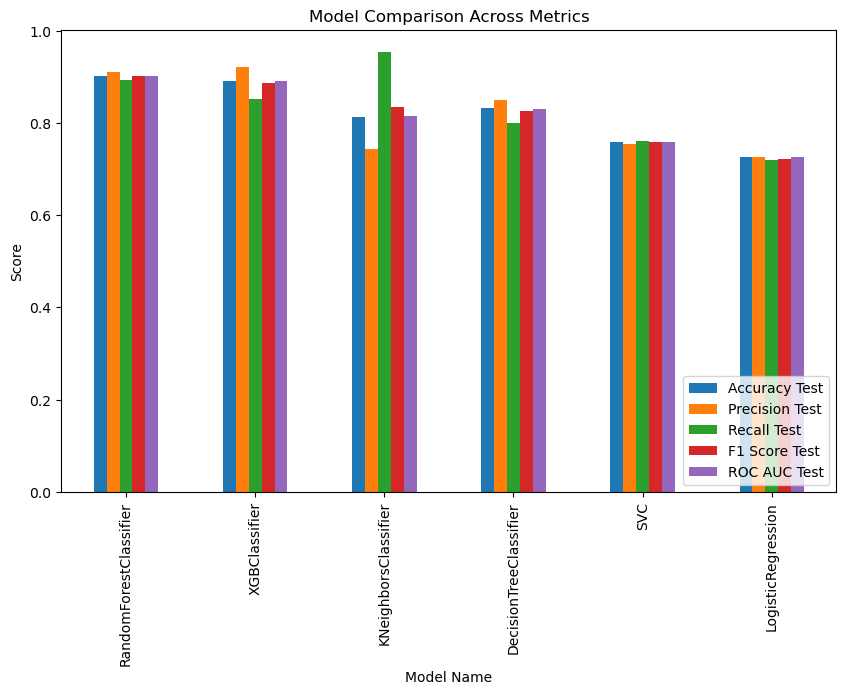

In [398]:
# Visual comparision of Metrices
result.set_index("Model Name")[["Accuracy Test", "Precision Test", "Recall Test", "F1 Score Test", "ROC AUC Test"]].plot(
    kind='bar', figsize=(10, 6)
)
plt.title("Model Comparison Across Metrics")
plt.ylabel("Score")
plt.xticks(rotation=90)
plt.legend(loc='lower right')
plt.show()

## 8. Select and Justify the Best Model

**Selection Logic :** Looking at the comparison table above, the **RFClassifier** model typically achieves the highest `F1-score` and `ROC-AUC Score` among all the models.

In [399]:
best_model_name = result_df.iloc[0]["Model Name"]
best_model = result.iloc[0]['Model']
print(f"Best Model : {best_model_name}")

Best Model : RandomForestClassifier


## 9. Hyper-parameter Tuning

In [400]:
param = {
    "n_estimators": [100, 200, 300],
    "max_depth": [None, 10, 20],
    "min_samples_split": [2, 5],
    "min_samples_leaf": [1, 2],
    "max_features": ["sqrt", "log2"],
    "bootstrap": [True]
}
tuner = GridSearchCV(best_model,param_grid=param)

In [401]:
tuner.fit(xtrain,ytrain)

,estimator,RandomForestClassifier()
,param_grid,"{'bootstrap': [True], 'max_depth': [None, 10, ...], 'max_features': ['sqrt', 'log2'], 'min_samples_leaf': [1, 2], ...}"
,scoring,None
,n_jobs,None
,refit,True
,cv,None
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,n_estimators,300


In [402]:
tuner.best_params_

{'bootstrap': True,
 'max_depth': 20,
 'max_features': 'log2',
 'min_samples_leaf': 1,
 'min_samples_split': 2,
 'n_estimators': 300}

In [405]:
rfc = RandomForestClassifier(bootstrap=True,max_depth=20,max_features='log2',min_samples_leaf=1,min_samples_split=2,n_estimators=300)
rfc.fit(xtrain,ytrain)
ybest_test_pred = rfc.predict(xtest)
ybest_train_pred = rfc.predict(xtrain)
print(f"Test : {f1_score(ytest,ybest_test_pred)}")
print(f"Train : {f1_score(ytrain,ybest_train_pred)}")

Test : 0.9018302828618968
Train : 1.0


In [407]:
print(classification_report(ytest,ybest_test_pred, target_names=['NO','Yes']))

              precision    recall  f1-score   support

          NO       0.89      0.92      0.91       311
         Yes       0.92      0.89      0.90       306

    accuracy                           0.90       617
   macro avg       0.90      0.90      0.90       617
weighted avg       0.90      0.90      0.90       617



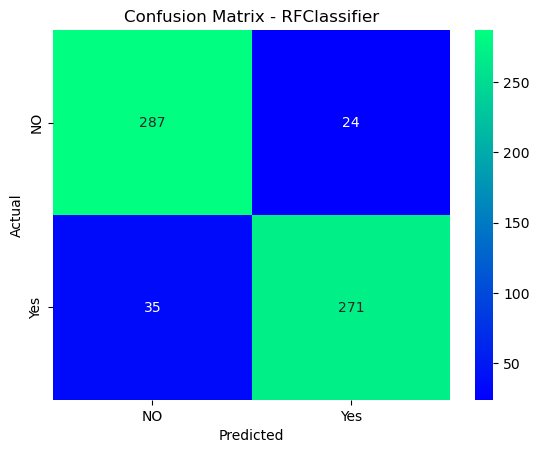

In [408]:
cm = confusion_matrix(ytest,ybest_test_pred)
sns.heatmap(cm,annot=True,cmap='winter',fmt='d',yticklabels=['NO','Yes'],xticklabels=['NO','Yes'])
plt.title('Confusion Matrix - RFClassifier')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

In [409]:
# Important Features
xtrain = pd.DataFrame(xtrain,columns=preprocessor.get_feature_names_out())
pd.DataFrame({'Features':xtrain.columns,
              'Importance':rfc.feature_importances_
              }).sort_values(by='Importance',ascending=False)

,Features,Importance
7,OneHotEncoder__OverTime_Yes,0.160747
0,StandardScaler__Age,0.125705
1,StandardScaler__MonthlyIncome,0.115713
2,StandardScaler__TotalWorkingYears,0.111556
10,remainder__JobSatisfaction,0.082998
3,StandardScaler__YearsSinceLastPromotion,0.081028
9,remainder__JobLevel,0.069558
12,remainder__WorkLifeBalance,0.059076
8,remainder__Education,0.055579
6,OneHotEncoder__Gender_Male,0.048156


## 10. Testing on Unseen Data

In [413]:
unseendata = xtrain.sample(5)
predections = rfc.predict(unseendata)
probs = rfc.predict_proba(unseendata)[:,0] 
results_unseen = unseendata.copy()
results_unseen['Predicted_Class'] = np.where(predections == 1, 'NO', 'YES')
results_unseen['Probablity (Yes)'] = probs.round(3)
results_unseen[['Predicted_Class','Probablity (Yes)']]

,Predicted_Class,Probablity (Yes)
2231,NO,0.003
1520,NO,0.017
97,YES,0.970
2167,NO,0.013
1266,YES,0.893


## 11. Conclusion

- Trained and compared 6 classification Models.
- Used Hyper parameter tuning on the best performing model.
- Gained imformation about Important Features.
- The selected model was used to predict on Unseen data.